In [10]:
import pandas as pd
import numpy as np
import re
import os
import string
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [12]:
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")

# 2. LISTAR los archivos reales que están dentro de esa ruta
print("Archivos encontrados en la ruta de Kaggle:")
print(os.listdir(path))

Using Colab cache for faster access to the 'rotten-tomatoes-movies-and-critic-reviews-dataset' dataset.
Archivos encontrados en la ruta de Kaggle:
['rotten_tomatoes_movies.csv', 'rotten_tomatoes_critic_reviews.csv']


In [56]:
# Celda 3: Carga de datos
path = kagglehub.dataset_download("stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset")
# Ajusta la ruta según los archivos que encuentres en 'path'
movies_df = pd.read_csv(f"{path}/rotten_tomatoes_movies.csv")
reviews_df = pd.read_csv(f"{path}/rotten_tomatoes_critic_reviews.csv")

# Selección de campos: Para un mejor contexto, podemos combinar título y crítica.
# Crearemos un campo 'texto_completo' para indexar.
movies_df['texto_para_indexar'] = reviews_df['review_content'].fillna('') + " [Pelicula: " + movies_df['movie_title'].fillna('') + "]"
print("Corpus cargado. Total de críticas:", len(reviews_df))

Using Colab cache for faster access to the 'rotten-tomatoes-movies-and-critic-reviews-dataset' dataset.
Corpus cargado. Total de críticas: 1130017


In [58]:
# Celda 4: Función de preprocesamiento avanzado
def preprocesar_texto(text):
    """Limpia el texto: minúsculas, elimina puntuación, números y espacios."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Elimina puntuación
    text = re.sub(r'\d+', '', text)     # Elimina números
    text = re.sub(r'\s+', ' ', text)    # Espacios redundantes
    return text.strip()

# Aplicamos el preprocesamiento a TODO el corpus ANTES de generar embeddings
print("Aplicando preprocesamiento...")
movies_df['texto_limpio'] = movies_df['texto_para_indexar'].apply(preprocess_text)
print("Preprocesamiento completado.")

Aplicando preprocesamiento...
Preprocesamiento completado.


In [60]:
# Celda 5: Generación de embeddings
print("Cargando el modelo de Sentence Transformers...")
modelo = SentenceTransformer('all-MiniLM-L6-v2')
print("Modelo cargado.")

# Obtenemos los textos ya preprocesados en una lista
documentos_limpios = movies_df['texto_limpio'].tolist()

# Generamos embeddings en lotes (batch_size=32 es un buen punto de partida)
print("Generando embeddings para todos los documentos...")
embeddings_documentos = modelo.encode(documentos_limpios, batch_size=32, show_progress_bar=True)
print("Embeddings generados con forma:", embeddings_documentos.shape)

Cargando el modelo de Sentence Transformers...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado.
Generando embeddings para todos los documentos...


Batches:   0%|          | 0/554 [00:00<?, ?it/s]

Embeddings generados con forma: (17712, 384)


In [61]:
# Celda 6: Función de búsqueda
def buscar(consulta, k=5):
    """
    Recibe una consulta, la preprocesa, genera su embedding y
    retorna los top-k documentos más similares.
    """
    # 1. Preprocesar la consulta
    consulta_limpia = preprocesar_texto(consulta)

    # 2. Generar el embedding de la consulta
    embedding_consulta = modelo.encode([consulta_limpia])

    # 3. Calcular la similitud del coseno contra todos los documentos
    # (Embeddings de docs ya están calculados)
    similitudes = cosine_similarity(embedding_consulta, embeddings_documentos)[0]

    # 4. Obtener los índices de los k documentos más similares
    indices_top_k = np.argsort(similitudes)[::-1][:k]

    # 5. Preparar los resultados en un DataFrame
    resultados = []
    for i, idx in enumerate(indices_top_k):
        resultados.append({
            'Ranking': i+1,
            'ID_Documento': idx,
            'Titulo_Pelicula': movies_df.loc[idx, 'movie_title'],
            'Fragmento_Texto': reviews_df.loc[idx, 'review_content'][:200] + "...", # Primeros 200 caracteres
            'Similitud': similitudes[idx]
        })
    return pd.DataFrame(resultados)

In [62]:
queries = [
    "Q1 science fiction movie with advanced technology",
    "Q2 romantic story with emotional relationships",
    "Q3 action movie with intense fight scenes",
    "Q4 horror film that creates fear and suspense",
    "Q5 visually impressive movie with weak storyline",
    "Q6 emotionally moving performance by the lead actor",
    "Q7 predictable plot but entertaining experience",
    "Q8 movie praised by critics but unpopular with audiences"
]

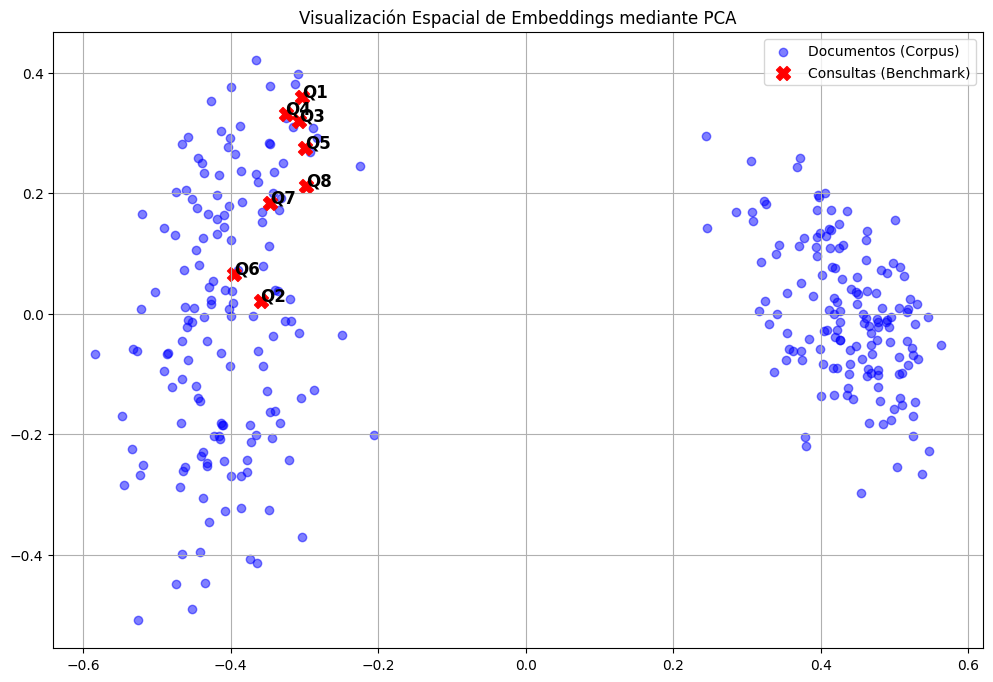

In [69]:
# Reducir dimensiones a 2D con PCA
pca = PCA(n_components=2)
# Ajustar con una porción de los documentos + las consultas
queries_embeddings = model_1.encode([preprocesar_texto(q) for q in queries])
todo_junto = np.vstack([embeddings_m1[:300], queries_embeddings]) # Tomamos 300 docs para no saturar el gráfico

transformado = pca.fit_transform(todo_junto)

plt.figure(figsize=(12, 8))
# Graficar documentos en azul
plt.scatter(transformado[:300, 0], transformado[:300, 1], alpha=0.5, label='Documentos (Corpus)', color='blue')
# Graficar consultas en rojo
plt.scatter(transformado[300:, 0], transformado[300:, 1], color='red', s=100, marker='X', label='Consultas (Benchmark)')

# Anotar los nombres de las consultas en el gráfico
for i, q in enumerate(queries):
    plt.annotate(f"Q{i+1}", (transformado[300+i, 0], transformado[300+i, 1]), fontsize=12, fontweight='bold')

plt.title('Visualización Espacial de Embeddings mediante PCA')
plt.legend()
plt.grid(True)
plt.show()

In [71]:
resumen_final = []
for i, q in enumerate(queries, 1):
    res = buscar(q, k=1).iloc[0] # Obtenemos el top-1 de cada consulta
    resumen_final.append({
        'Consulta': f'Q{i}',
        'Documento Top-1 ID': res['ID_Documento'],
        'Título Película': res['Titulo_Pelicula'],
        'Similitud': round(res['Similitud'], 4)
    })
pd.DataFrame(resumen_final)

,Consulta,Documento Top-1 ID,Título Película,Similitud
0,Q1,9468,Licence To Kill,0.5729
1,Q2,12592,Road Hard,0.5667
2,Q3,15191,The Hunt (Jagten),0.5723
3,Q4,6138,Everybody Knows... Elizabeth Murray,0.6218
4,Q5,11782,Phantasm: Ravager,0.5637
5,Q6,3360,Before I Fall,0.4932
6,Q7,12014,The President's Analyst,0.5274
7,Q8,12159,Pusher III: I'm the Angel of Death,0.5326
